Merci de **ne pas modifier** le nom de ce notebook (même pour y inclure son nom).

Quelques conseils:
- pour exécutez une cellule, cliquez sur le bouton *Exécuter* ci-dessus ou tapez **Shift+Enter**
- si l'exécution d'une cellule prend trop de temps, sélectionner dans le menu ci-dessus *Noyau/Interrompre*
- en cas de très gros plantage *Noyau/Redémarrer*
- **sauvegardez régulièrement vos réponses** en cliquant sur l'icone disquette ci-dessus à gauche, ou *Fichier/Créer une nouvelle sauvegarde*

----------------------------------------------------------------------------

# MethNum : Devoir à la maison
## A rendre avant le lundi 23 octobre 2023 à midi

### BAREME :
**Le barème complet comporte 31 points, plus 9 points Bonus** 
- Exercice 1 sur le dimensionement de la porte d'autobus : 17 points + 3 points Bonus
- Exercice 2 sur l'aiguille de Buffon: 14 points
- Qualité du code: organisation, commentaires,... : 6 points Bonus

## Exercice 1: dimensionnement de la hauteur de porte d'un autobus

Les contraintes de structure de l'autobus imposent de choisir la hauteur des portes aussi petite que possible. La société commanditaire des autobus souhaite que la proportion des personnes qui sont obligées de courber la tête (au risque de se cogner le front) pour passer la porte soit de 0,1%. Le constructeur de l'autobus préfèrerait que cette proportion soit plutôt de 1%.
Le but du problème consiste à déterminer les valeurs correspondantes de la hauteur de porte, à partir de la distribution des tailles d'un échantillon d'environ 1000 personnes:

- Taille (mètres) :   1.5, 1.55 , 1.6 , 1.65 , 1.7 , 1.75 , 1.8 , 1.85 ,  1.9 , 1.95 , 2.0 , 2.05 , 2.1 , 2.15, 2.2,
- Nombre d'individus :  1,    7 ,  26 ,   71 , 120 ,  148 , 194 ,  143 , 120 ,   59 ,  21 ,  6 ,   0 , 1, 0
- Incertitude sur ce nombre :  1.5 ,  2.6, 5.1,  8.4, 11.0, 12.2, 13.9, 12.0, 11.0,  7.7, 4.6,  2.4,  1.,  1.5,   1.

1. Représenter graphiquement le nombre d'individus en fonction de la taille, ainsi que la barre d'erreur sur ce nombre. Pour chaque valeur de la taille listée dans le tableau, calculer le pourcentage d'individus strictement plus grands que cette taille.

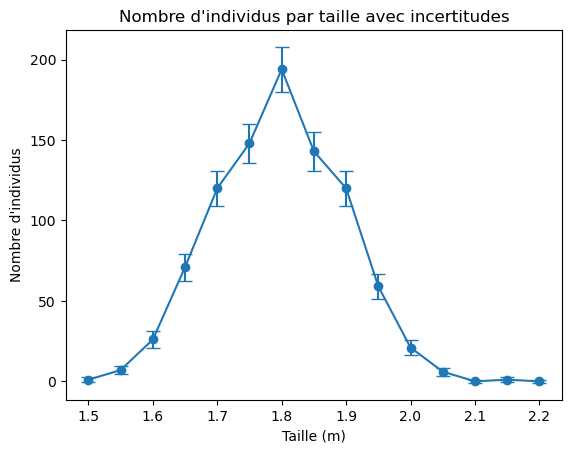

Pour la taille de 1.5m, 99.89% des individus sont plus grands.
Pour la taille de 1.55m, 99.13% des individus sont plus grands.
Pour la taille de 1.6m, 96.29% des individus sont plus grands.
Pour la taille de 1.65m, 88.55% des individus sont plus grands.
Pour la taille de 1.7m, 75.46% des individus sont plus grands.
Pour la taille de 1.75m, 59.32% des individus sont plus grands.
Pour la taille de 1.8m, 38.17% des individus sont plus grands.
Pour la taille de 1.85m, 22.57% des individus sont plus grands.
Pour la taille de 1.9m, 9.49% des individus sont plus grands.
Pour la taille de 1.95m, 3.05% des individus sont plus grands.
Pour la taille de 2.0m, 0.76% des individus sont plus grands.
Pour la taille de 2.05m, 0.11% des individus sont plus grands.
Pour la taille de 2.1m, 0.11% des individus sont plus grands.
Pour la taille de 2.15m, 0.00% des individus sont plus grands.
Pour la taille de 2.2m, 0.00% des individus sont plus grands.


In [4]:
import matplotlib.pyplot as plt

# Données fournies
tailles = [1.5, 1.55, 1.6, 1.65, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2]
nombre_individus = [1, 7, 26, 71, 120, 148, 194, 143, 120, 59, 21, 6, 0, 1, 0]
incertitudes = [1.5, 2.6, 5.1, 8.4, 11.0, 12.2, 13.9, 12.0, 11.0, 7.7, 4.6, 2.4, 1., 1.5, 1.]

# 1. Représenter graphiquement le nombre d'individus en fonction de la taille, avec barre d'erreur
plt.errorbar(tailles, nombre_individus, yerr=incertitudes, fmt='o-', capsize=5)
plt.xlabel('Taille (m)')
plt.ylabel('Nombre d\'individus')
plt.title('Nombre d\'individus par taille avec incertitudes')
plt.show()
# 2. Calculer le pourcentage d'individus strictement plus grands que chaque taille

# Initialisation de la liste pour stocker les pourcentages
pourcentages = []

# Itération sur chaque taille
for i in range(len(tailles)):
    compteur = 0  # Pour compter le nombre d'individus plus grands que la taille actuelle
    
    # Itération sur toutes les tailles suivantes
    for j in range(i+1, len(tailles)):
        compteur += nombre_individus[j]
    
    # Calcul du pourcentage
    pourcentage = (compteur / total_individus) * 100
    pourcentages.append(pourcentage)
    print(f"Pour la taille de {tailles[i]}m, {pourcentages[-1]:.2f}% des individus sont plus grands.")

2. Sur la base de cet échantillon, pouvez-vous estimer à 5cm près la hauteur de porte telle que au moins 99% des individus passent cette porte sans se cogner ? Même question pour au moins 99,9% des individus ? A combien estimez-vous l'incertitude sur ces chiffres ?

pour que 99% des individus passe la porte sans se cogner il faut que la porte soit à environ 2.00m.

pour que 99.9% des individus passe la porte sans se cogner il faut que la porte soit à environ 2.10m.

Pour 2.00m : L'incertitude est de 4.6 individus.

Pour 2.10m : L'incertitude est de 1.0 individus (en se basant sur l'incertitude fournie pour 2.1m)

Pour obtenir une meilleure précision, on fait l'hypothèse que la distribution des tailles $t$ suit une loi de Gauss: 

$$f(t) = A e^{-\frac{(t-t_{moy})^2}{2 \sigma^2} }$$ 

où $t_{moy}$ est la taille moyenne, $\sigma$ est l'écart type et $A$ une constante. 

La détermination des paramètres de cette loi de Gauss par ajustement utilise toutes les données disponibles pour l'ensemble des individus de l'échantillon. Si l'hypothèse d'une loi de Gauss est correcte, alors cet ajustement permet de déterminer beaucoup plus précisément les proportions d'individus de très grande taille, et donc les hauteurs de porte qui conviennent.


3. Ajuster la distribution de taille précédente par une loi de Gauss : 
- donner la valeur des paramètres obtenus (taille moyenne, écart-type sur la taille, constante A) et l'incertitude sur ces paramètres. Vérifier que, lorsqu'on choisit ces valeurs des paramètres comme valeurs initiales de l'ajustement et qu'on refait tourner cet ajustement, on arrive bien au même résultat.
    
- calculer les résidus (écart, pour chaque valeur de taille, entre le nombre d'individus réel et le nombre d'individus prévu par la courbe ajustée).
- calculer le $\chi^2$ réduit et déterminer si l'ajustement est fiable.
- sur un graphique, représenter sous forme de points les données du tableau et sous forme de courbe la courbe ajustée.

A = 179.24 ± 5.37
t_moy = 1.80m ± 0.00m
sigma = 0.10m ± 0.00m
Chi^2 réduit = 1.08


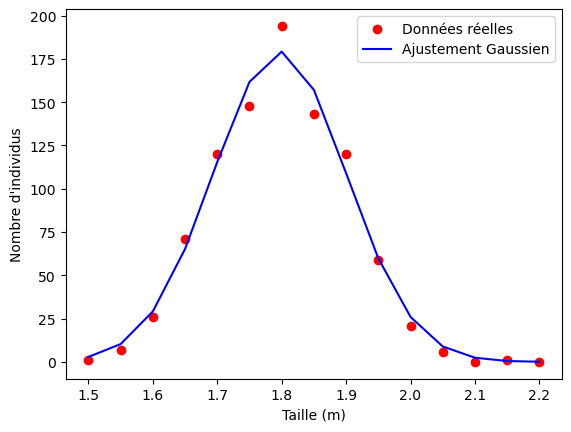

In [6]:
from scipy.optimize import curve_fit

# Données
tailles = np.array([1.5, 1.55, 1.6, 1.65, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2])
nombre_individus = np.array([1, 7, 26, 71, 120, 148, 194, 143, 120, 59, 21, 6, 0, 1, 0])

# Fonction gaussienne
def gauss(t, A, tmoy, sigma):
    return A * np.exp(-((t - tmoy)**2) / (2 * sigma**2))

# Ajustement
parametres, covariance = curve_fit(gauss, tailles, nombre_individus, p0=[200, 1.8, 0.15])
A, tmoy, sigma = parametres
incertitudes = np.sqrt(np.diag(covariance))

print(f"A = {A:.2f} ± {incertitudes[0]:.2f}")
print(f"t_moy = {tmoy:.2f}m ± {incertitudes[1]:.2f}m")
print(f"sigma = {sigma:.2f}m ± {incertitudes[2]:.2f}m")

# Résidus
residus = nombre_individus - gauss(tailles, *parametres)

# Chi-carré réduit
chi2 = sum((residus**2) / gauss(tailles, *parametres))
dof = len(tailles) - len(parametres)  # Degrés de liberté
chi2_reduit = chi2 / dof
print(f"Chi^2 réduit = {chi2_reduit:.2f}")

# Graphique
plt.scatter(tailles, nombre_individus, label='Données réelles', color='red')
plt.plot(tailles, gauss(tailles, *parametres), label='Ajustement Gaussien', color='blue')
plt.xlabel('Taille (m)')
plt.ylabel('Nombre d\'individus')
plt.legend()
plt.show()

LA REPONSE ICI (double-clique pour editer la cellule)

4. Calculer l'intégrale $I$ de la fonction ajustée entre $-\infty$ et $+\infty$.

On rappelle que, lorsqu'on intègre une fonction $f(x, p_1, p_2, p_3)$ avec ```trapz```, alors l'intégration porte sur le premier argument (ici $x$), les autres arguments $p_1$,$p_2$ et $p_3$ étant traités comme des paramètres: ```I=integrate.trapz(f(x,p1,p2,p3),x)```.

In [7]:
from scipy import integrate

# Définition de la plage d'intégration
x = np.linspace(tmoy - 10*sigma, tmoy + 10*sigma, 10000)

# Calcul de l'intégrale
I = integrate.trapz(gauss(x, A, tmoy, sigma), x)

print(f"Intégrale de la fonction gaussienne sur [-infini, +infini] ≈ {I:.2f}")

Intégrale de la fonction gaussienne sur [-infini, +infini] ≈ 46.42


5. En déduire la distribution de probabilité de taille des individus $p(t)=f(t)/I$ (de cette manière l'intégrale de $p(t)$ de ${-\infty}$ à ${+\infty}$ vaut 1). Représenter graphiquement $p(t)$, et vérifier que cette intégrale est effectivement égale à 1 avec une précision raisonnable.

Intégrale de p(t) sur [-infini, +infini] = 1.00000


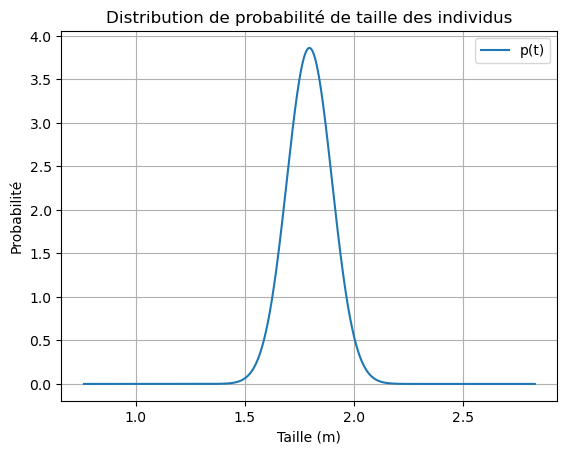

In [8]:
# Définition de la distribution de probabilité p(t)
def p(t):
    return gauss(t, A, tmoy, sigma) / I

# Vérification de l'intégrale de p(t)
integrale_pt = integrate.trapz(p(x), x)

# Affichage de l'intégrale de p(t)
print(f"Intégrale de p(t) sur [-infini, +infini] = {integrale_pt:.5f}")

# Représentation graphique de p(t)
plt.plot(x, p(x), label='p(t)')
plt.xlabel('Taille (m)')
plt.ylabel('Probabilité')
plt.title('Distribution de probabilité de taille des individus')
plt.legend()
plt.grid(True)
plt.show()

6. Pour des valeurs $t_{min}$ allant de 1.9m à 2.3m par pas de 0.02m, déterminer la fonction $P(t_{min})=\int^{+\infty}_{t_{min}} p(t) dt$, qui représente la probabilité que la taille d'un individu soit supérieure à $t_{min}$ . 

Pour ce calcul, on remplacera la borne supérieure infinie de l'intégrale par une valeur $t_{max}$ qui permette d'obtenir à la fois une précision numérique suffisante sur cette intégrale et une différence négligeable par rapport à une intégrale jusqu'à l'infini. On suggère de choisir $t_{max}=t_{moy}+10$ m.

On créera un tableau contenant les valeurs de $t_{min}$ et un autre contenant les valeurs de $P(t_{min})$.
Représenter graphiquement  $P(t_{min})$ en fonction de $t_{min}$. On choisira une échelle logarithmique pour représenter $P(t_{min})$ (axe vertical).

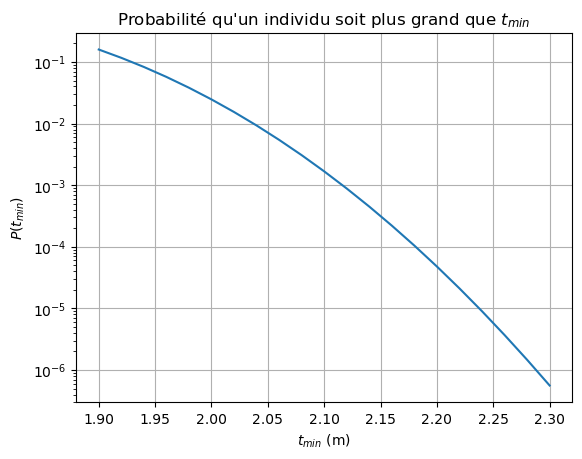

In [9]:
t_max = tmoy + 10
t_mins = np.arange(1.9, 2.3 + 0.02, 0.02)  # Création du tableau de t_min

# Calcul de P(t_min)
P_values = [integrate.trapz(p(np.linspace(t_min, t_max, 10000)), np.linspace(t_min, t_max, 10000)) for t_min in t_mins]

# Représentation graphique
plt.plot(t_mins, P_values)
plt.yscale('log')  # Échelle logarithmique pour l'axe vertical
plt.xlabel('$t_{min}$ (m)')
plt.ylabel('$P(t_{min})$')
plt.title('Probabilité qu\'un individu soit plus grand que $t_{min}$')
plt.grid(True)
plt.show()

7. Déterminer les valeur de $t_{min}$ correspondant à $P(t_{min}) = 0.01$ et à $P(t_{min}) = 0.001$. Comparer aux estimations de la question 1.

**BONUS :** Pour effectuer une détermination précise de ces valeurs vous pouvez utiliser la fonction ```interp``` de ```numpy```. 
A partir d'un tableau de valeurs $t_{min}$ et du tableau correspondant $P(t_{min})$, elle permet de déterminer par interpolation quelle valeur de t correspond à une valeur donnée de $P$, si cette dernière n'est pas dans le tableau de valeurs $P(t_{min})$. Cette fonction prend en argument la valeur de $P$, en second argument le tableau des $P(t_{min})$ dans lequel on positionne $P$, et en troisième argument le tableau des $t_{min}$, duquel on extrait la valeur interpolée de $t_{min}$. Par ailleurs, il convient que les nombres du tableau $P(t_{min})$ soient parcourus dans l'ordre croissant, c'est à dire que l'indice de ce tableau doit aller de sa valeur la plus grande à 0 par pas de -1. Les lignes de code correspondantes sont les suivantes:

```t_pour_cent = np.interp(0.01, P[P.size:0:-1],t_min[P.size:0:-1])```

```t_pour_mille = np.interp(0.001, P[P.size:0:-1],t_min[P.size:0:-1])```

In [10]:
# Interpolation
t_pour_cent = np.interp(0.01, P_values[::-1], t_mins[::-1])
t_pour_mille = np.interp(0.001, P_values[::-1], t_mins[::-1])

print(f"Valeur de t_min pour P(t_min) = 0.01: {t_pour_cent:.2f}m")
print(f"Valeur de t_min pour P(t_min) = 0.001: {t_pour_mille:.2f}m")

Valeur de t_min pour P(t_min) = 0.01: 2.04m
Valeur de t_min pour P(t_min) = 0.001: 2.12m


## Exercice 2: Aiguille de Buffon

Georges-Louis Leclerc, comte de Buffon (1707-1788) est surtout connu comme un naturaliste qui a influencé Lamarck et Darwin. C'était aussi un industriel avant l'heure, qui avait construit un haut-fourneau et des forges sur son domaine de Montbard (Côte d'Or). 

Buffon s'est aussi intéressé à la cosmologie et aux mathématiques. On lui doit le problème suivant: 

Etant donné un parquet formé de planches de largeur $L_P$, sur lequel tombe une aiguille de longueur $L_A$, quelle est la probabilité que l'aiguille tombe à cheval sur deux planches ?

<img src="AiguilleBuffon.png" width="75%" />

Pour mesurer cette probabilité, on va simuler le lâcher aléatoire d'un grand nombre d'aiguilles et compter la fraction de celles qui tombent à cheval sur deux planches.

On utilise un axe $x$ perpendiculaire aux planches et un axe $y$ aligné avec les planches du parquet. On repère la position d'une aiguille par l'angle $\theta$ qu'elle fait avec l'axe $x$ et par la distance entre son centre $x_C$ et le bord gauche de la planche sur laquelle ce centre se trouve (voir croquis).

Pour toute la suite de l'exercice, on choisit $L_P = 5 cm$ et $L_A = 4 cm$

**1.** Ecrire une fonction _SurDeuxPlanches_, prenant comme arguments les valeurs $\theta$ et $x_C$ caractérisant la position d'une aiguille sur le plancher, et qui renvoie une variable logique _Vraie_ si l'aiguille est à cheval sur deux planches et _Fausse_ autrement.

On notera que, si $a$ est un nombre flottant positif ou négatif, la fonction $floor(a)$ du module $math$ fournit l'entier immédiatement inférieur à $a$.

In [12]:
import math

def SurDeuxPlanches(theta, x_C, L_P=5, L_A=4):
    # Calcul des positions des extrémités
    x_gauche = x_C - (L_A / 2) * math.cos(theta)
    x_droite = x_C + (L_A / 2) * math.cos(theta)
    
    # Comparaison des valeurs plancher pour déterminer si l'aiguille est à cheval sur deux planches
    if math.floor(x_gauche/L_P) != math.floor(x_droite/L_P):
        return True
    else:
        return False

**2.** Effectuer $N = 100\ 000$ lâchers d'aiguilles avec une probabilité uniforme de l'angle $\theta$ de l'aiguille avec l'axe $x$ entre $0$ et $2\pi$ et une probabilité uniforme de la position $x_C$ entre $L_P$ et $2L_P$ (pour que les coordonnées des extrémités soient toujours positives). 

Pour chaque aiguille, on formera une liste comportant $\theta$ et $x_C$ dans cet ordre. On formera ensuite une liste de listes, $Liste_A$, correspondant aux $N$ aiguilles.

In [14]:
import random

N = 100000
L_P = 5  # en cm

def lacher_aiguille():
    theta = random.uniform(0, 2 * math.pi)
    x_C = random.uniform(L_P, 2 * L_P)
    return [theta, x_C]

Liste_A = [lacher_aiguille() for _ in range(N)]

**3.** Calculer la proportion $P$ d'aiguilles à cheval sur deux planches

En déduire que la quantité $\frac{2*L_A}{P*L_P}$ semble une bonne approximation de $\pi$...

In [15]:
# Compter le nombre d'aiguilles à cheval sur deux planches
compte_cheval = sum([SurDeuxPlanches(theta, x_C) for theta, x_C in Liste_A])

# Calculer la proportion P
P = compte_cheval / N

print(f"Proportion P d'aiguilles à cheval sur deux planches = {P:.4f}")

# Estimation de pi
L_A = 4  # en cm
pi_estime = (2 * L_A) / (P * L_P)

print(f"Estimation de pi basée sur l'expérience de Buffon = {pi_estime:.4f}")

Proportion P d'aiguilles à cheval sur deux planches = 0.5100
Estimation de pi basée sur l'expérience de Buffon = 3.1372


**4.** Ordonner la liste $Liste_A$ de manière que les aiguilles soient ordonnées par valeurs croissantes de l'angle $\theta$

On pourra pour cela utiliser la fonction $Liste_A.sort()$, qui permet d'ordonner la liste de listes $Liste_A$ selon l'ordre croissant du premier élément de chaque élément de cette liste de listes (élément qui est lui-même une liste)

Créer les listes $Liste_X$ et $Liste_Y$, avec la seule valeur 0 dans chacune.

Translater la première aiguille de manière que sa première extrémité soit en $x=0$, $y=0$. Calculer et Enregistrer dans des listes $Liste_X$ et $Liste_Y$ les coordonées $x$ et $y$ de la seconde extrémité. Translater l'aiguille suivante pour que sa première extrémité coincide avec la seconde extrémité de l'aiguille précédente, et enregistrer dans $Liste_X$ et $Liste_Y$ respectivement les coordonnées $x$ et $y$ de la seconde extrémité de cette aiguille. Procéder de même pour l'ensemble des aiguilles. 

Les listes $Liste_X$ et $Liste_Y$ contiennent alors la liste des extrémités des aiguilles, ordonnées suivant des valeurs croissantes de $\theta$ et mises bout à bout. 

Faire un graphique représentant toutes les aiguilles ainsi positionnées et remarquer que, si $N$ tend vers l'infini, la courbe semble tendre vers un cercle.

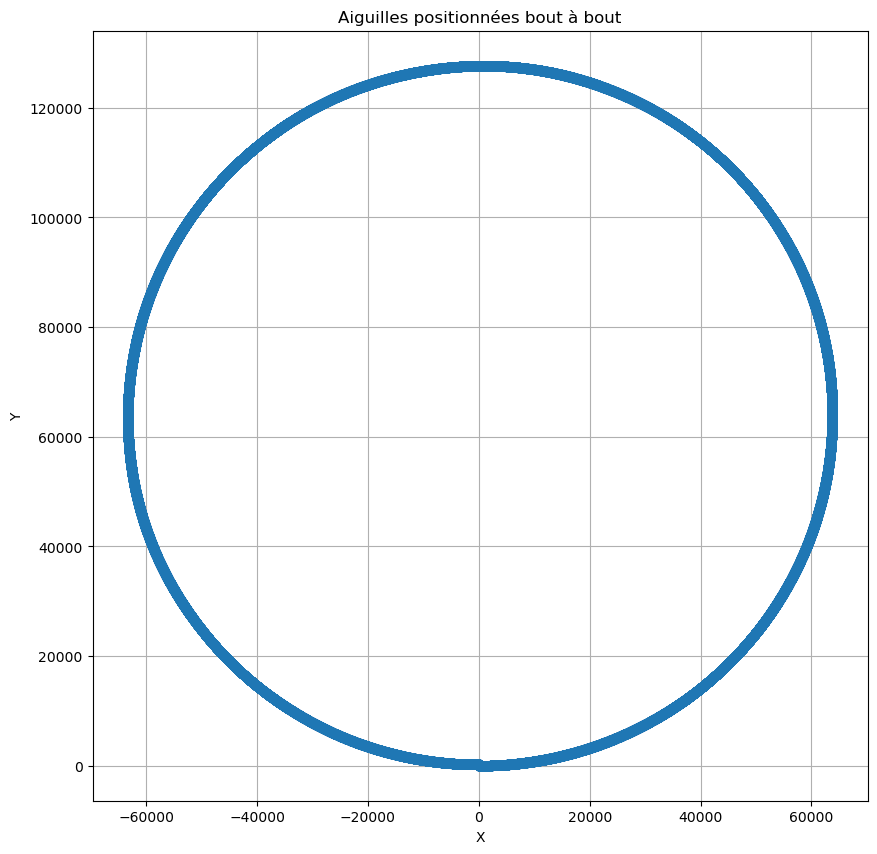

In [16]:
import matplotlib.pyplot as plt

# 1. Ordonner Liste_A en fonction de theta
Liste_A.sort(key=lambda x: x[0])

# 2. Créer les listes Liste_X et Liste_Y
Liste_X = [0]
Liste_Y = [0]

# 3. Translater chaque aiguille et ajouter ses coordonnées à Liste_X et Liste_Y
for theta, x_C in Liste_A:
    x_new = Liste_X[-1] + L_A * math.cos(theta)
    y_new = Liste_Y[-1] + L_A * math.sin(theta)
    
    Liste_X.append(x_new)
    Liste_Y.append(y_new)

# 4. Tracer la courbe résultante
plt.figure(figsize=(10,10))
plt.plot(Liste_X, Liste_Y, '-o')
plt.title("Aiguilles positionnées bout à bout")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

**5.** Lorsque $N$ est assez grand, l'angle entre une aiguille et la suivante (après classement en $\theta$ croissant) est en moyenne de $\delta\theta = 2\pi/N$. De ce fait, la courbe formée des $N$ aiguilles mises bout à bout tend vers un polygone **fermé** à $N$ côtés. Si $N$ tend vers l'infini, cette courbe tend donc vers un cercle.

Exprimer la circonférence, puis le diamètre de ce cercle en fonction de $N$ et de $L_A$

Combien de limites entre deux planches de parquet le diamètre horizontal du cercle croise-t-il ? En déduire une formule analytique donnant la fraction $F$ des aiguilles à cheval entre deux planches.

## Qualité du code (6 points)

- Le code est-il bien commenté ?
- Les variables ont des noms explicites et clairs ?